# CortexCall — Data Loading Verification & Exploratory Data Analysis
### EEG Motor Imagery Classification (LEFT vs RIGHT)

**Phase:** Week 1 — Data Loading Verification + EDA

This notebook has three parts:

- **Part 0 — Data Loading Verification & Correction.** Before trusting any EDA number, we re-verify the
  loading/alignment logic itself rather than assuming the shared `DataLoader` got it right. This is where
  we investigate the duplicate/conflicting-label issue found in an earlier pass, in depth.
- **Part 1 — Core EDA.** Structural usability, class balance, missing values, time/sampling checks,
  amplitude distributions, time- and frequency-domain LEFT vs RIGHT comparisons — all run on the
  **corrected** dataset from Part 0.
- **Part 2 — Preprocessing Investigation & Refined EDA.** Investigates whether line-noise/drift removal is
  actually needed (it is), redoes the frequency-domain comparison properly (corrected sampling rate,
  multiple-comparison correction, effect sizes), and stress-tests the "is there a signal at all" question
  with a cross-validated multivariate check.

As in the project's EDA rules: **raw files are never modified**. All corrections here (dropping specific
trial IDs, filtering) happen in-memory, are fully documented, and are meant to be reviewed by the
instructor/team before being adopted permanently.

> Run this notebook from the `notebooks/` folder so the relative paths in `src/data_loader.py`
> (`data_dir="../data"`) resolve correctly.


In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy import stats
from scipy.stats import false_discovery_control

from data_loader import DataLoader

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

_trapz = getattr(np, "trapezoid", None) or np.trapz
def band_power(f, pxx, low, high):
    mask = (f >= low) & (f <= high)
    return _trapz(pxx[mask], f[mask])

def welch_psd(values, fs, nperseg=512):
    nperseg = min(nperseg, len(values))
    f, pxx = sps.welch(values, fs=fs, nperseg=nperseg)
    return f, pxx


---
# Part 0 — Data Loading Verification & Correction

We don't start EDA by trusting `src/data_loader.py`'s output blindly. We re-verify each step of the
loading/alignment pipeline independently, then specifically dig into the duplicate/conflicting-label finding
from the previous pass, since it's the kind of thing that — if it's a systematic bug — could affect more than
just the trials it's directly visible in.


## 0.1 Independently Re-Verify `labels.csv`

Don't trust `DataLoader`'s internal handling of the labels file — reload it raw and check its shape,
column structure, and value distribution ourselves.


In [2]:
labels_raw = pd.read_csv("../data/labels.csv")
print("Shape:", labels_raw.shape)
print("Columns:", labels_raw.columns.tolist())
print("Any nulls:", labels_raw.isna().sum().sum())
print()
print(labels_raw.iloc[:, 0].value_counts(dropna=False))
labels_raw.head()


Shape: (2400, 1)
Columns: ['label']
Any nulls: 0

label
Right    1213
Left     1187
Name: count, dtype: int64


,label
0,Left
1,Right
2,Left
3,Left
4,Left


**Check:** 2,400 rows, one column, no nulls, values are `Left`/`Right` (mixed case — the shared loader
lowercases these, which we'll re-verify is applied correctly below). This matches the Data-Loading report's
documented starting point.


## 0.2 Independently Re-Verify File Discovery

Re-run the file discovery/naming-pattern check ourselves rather than trusting `check_eeg_files.py`'s
past output. We want zero assumptions carried over from the original scripts.


In [3]:
import glob, re

EEG_FOLDER = "../data/MI CSV"
file_paths = glob.glob(os.path.join(EEG_FOLDER, "*.csv"))
pattern = re.compile(r"cellula_MI_data_(\d+)\.csv$", re.IGNORECASE)

parsed = []
unparsed = []
for fp in file_paths:
    fn = os.path.basename(fp)
    m = pattern.match(fn)
    if m:
        parsed.append({"trial_id": int(m.group(1)), "path": fp})
    else:
        unparsed.append(fn)

parsed_df = pd.DataFrame(parsed).sort_values("trial_id").reset_index(drop=True)
print(f"Files found: {len(file_paths)}")
print(f"Files matching expected naming pattern: {len(parsed_df)}")
print(f"Files NOT matching (unexpected names): {len(unparsed)}")
if unparsed:
    print(unparsed)

ids = parsed_df["trial_id"].values
print(f"ID range: {ids.min()}–{ids.max()}")
print(f"Unique IDs: {len(set(ids))} / {len(ids)}  (duplicated filenames: {len(ids) - len(set(ids))})")
print(f"Missing IDs in 1..{ids.max()}: {sorted(set(range(1, ids.max()+1)) - set(ids))}")


Files found: 2160
Files matching expected naming pattern: 2160
Files NOT matching (unexpected names): 0
ID range: 1–2160
Unique IDs: 2160 / 2160  (duplicated filenames: 0)
Missing IDs in 1..2160: []


**Check:** confirms the Data-Loading report's claim independently — 2,160 files, continuous IDs
1–2,160, no missing or duplicate *filenames*. (Note: "no duplicate filenames" is different from "no duplicate
*content*" — two different filenames can still contain byte-identical data, which is exactly the issue we
investigate next.)


## 0.3 Load via the Shared `DataLoader` — as a Starting Point, Not a Final Answer

We do use the shared `DataLoader` (per the project's "don't rewrite alignment logic in notebooks" rule) —
but we treat its output manifest as a **hypothesis to verify**, not ground truth.


In [4]:
dl = DataLoader(data_dir="../data")
manifest_raw = dl.valid_manifest.copy()
print(f"Trials in manifest: {len(manifest_raw)}")
assert len(manifest_raw) == 2160
assert manifest_raw['trial_id'].is_unique
manifest_raw.head()


Found 2160 signal files in ../data/MI CSV
[DataLoader] found 2400 labels and 2160 signal files.
DataLoader: Dropping last 240 extra labels to align with signal files.
[DataLoader] successfully aligned 2160 EEG trials with labels.
Trials in manifest: 2160


,trial_id,file_path,label
0,1,../data/MI CSV/cellula_MI_data_1.csv,left
1,2,../data/MI CSV/cellula_MI_data_2.csv,right
2,3,../data/MI CSV/cellula_MI_data_3.csv,left
3,4,../data/MI CSV/cellula_MI_data_4.csv,left
4,5,../data/MI CSV/cellula_MI_data_5.csv,left


## 0.4 Duplicate-Content Detection

The naming/ID checks above only rule out duplicate *filenames*. We now hash each trial's full numeric
content (all 5 columns, including `Time`) to find trials that are byte-for-byte identical despite having
different filenames/trial IDs.


In [5]:
def trial_hash(path):
    df = pd.read_csv(path)
    return hashlib.md5(pd.util.hash_pandas_object(df, index=False).values.tobytes()).hexdigest()

manifest_raw['content_hash'] = manifest_raw['file_path'].apply(trial_hash)
dup_mask = manifest_raw['content_hash'].duplicated(keep=False)
duplicate_trials = manifest_raw[dup_mask].sort_values('content_hash')

print(f"Trials that are byte-for-byte duplicates of another trial: {len(duplicate_trials)}")
print(f"Duplicate-content groups: {manifest_raw.loc[dup_mask, 'content_hash'].nunique()}")
duplicate_trials[['trial_id', 'label', 'content_hash']]


Trials that are byte-for-byte duplicates of another trial: 72
Duplicate-content groups: 36


,trial_id,label,content_hash
1319,1320,left,0e4ac99849daa8da308540217a3463a8
671,672,left,0e4ac99849daa8da308540217a3463a8
1317,1318,left,15be9a4df4e454c4910ac839599a0693
669,670,left,15be9a4df4e454c4910ac839599a0693
923,924,right,1d36353ac2d53eae28a032b1e6087252
680,681,left,1d36353ac2d53eae28a032b1e6087252
38,39,right,2782fc40f00919a8ab15a0b8a35b72f7
1073,1074,left,2782fc40f00919a8ab15a0b8a35b72f7
1960,1961,left,28eef7a147e5711b83130801244e92c0
1402,1403,left,28eef7a147e5711b83130801244e92c0


In [6]:
# How many of these duplicate-content groups have a LABEL CONFLICT (identical signal, different label)?
dup_groups = duplicate_trials.groupby('content_hash')['label'].nunique()
n_consistent = (dup_groups == 1).sum()
n_conflicting = (dup_groups > 1).sum()
print(f"Duplicate groups with CONSISTENT label: {n_consistent}")
print(f"Duplicate groups with CONFLICTING label (same signal, different label): {n_conflicting}")


Duplicate groups with CONSISTENT label: 12
Duplicate groups with CONFLICTING label (same signal, different label): 24


**Confirmed: the duplicate/conflicting-label issue is real** — 72 trials forming 36 duplicate-content
pairs, with 24 of those 36 pairs (67%) carrying conflicting LEFT/RIGHT labels on identical signal content.
This can't be a coincidence of two similar-looking noisy trials — the hash includes the `Time` column too, so
this means the entire file, timestamps included, was saved twice under two different names. This needs a
proper investigation, not just a "drop one, keep one" footnote.


## 0.5 Do the Duplicates Correspond to Specific Blocks? (Plotting Trial ID vs. Label)

First, a global view: plot every trial's label against its trial ID, marking the duplicate-content trial IDs,
to see whether they cluster or scatter.


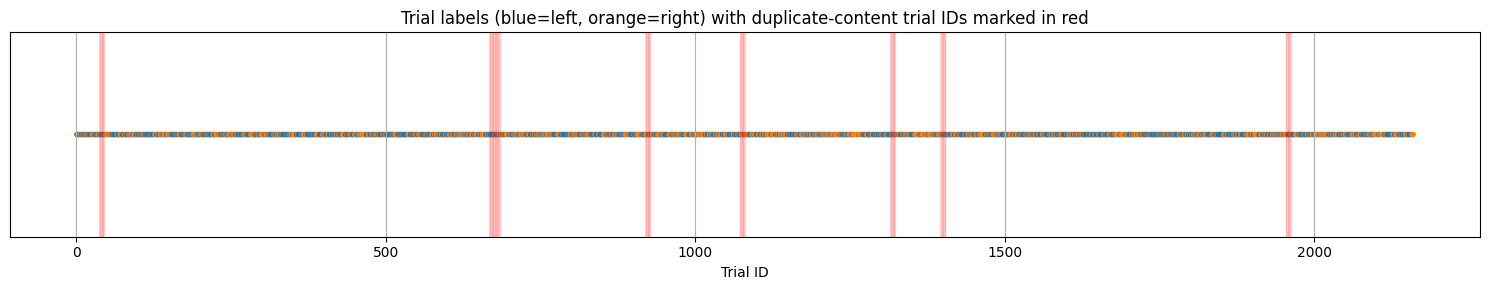

In [7]:
dup_ids = set(duplicate_trials['trial_id'])

fig, ax = plt.subplots(figsize=(15, 3))
colors = manifest_raw.sort_values('trial_id')['label'].map({'left': 'tab:blue', 'right': 'tab:orange'})
ax.scatter(manifest_raw.sort_values('trial_id')['trial_id'], np.zeros(len(manifest_raw)), c=colors, s=8)
for tid in dup_ids:
    ax.axvline(tid, color='red', alpha=0.15, lw=1)
ax.set_yticks([])
ax.set_xlabel('Trial ID')
ax.set_title('Trial labels (blue=left, orange=right) with duplicate-content trial IDs marked in red')
plt.tight_layout()
plt.show()


## 0.6 Structure of Each Duplicate Pair — Offsets and Contiguity

For every duplicate-content pair, record the two trial IDs, their offset, and whether their labels conflict.
Then check whether the offsets and IDs form a pattern (a "casual coincidence" theory predicts scattered,
irregular offsets; a "pipeline bug" theory predicts a small number of repeated, structured offsets).


In [8]:
pair_info = []
for h, grp in duplicate_trials.groupby('content_hash'):
    ids = sorted(grp['trial_id'].tolist())
    labs = grp.set_index('trial_id').loc[ids, 'label'].tolist()
    if len(ids) == 2:
        pair_info.append({'id_lo': ids[0], 'id_hi': ids[1], 'offset': ids[1] - ids[0],
                           'label_lo': labs[0], 'label_hi': labs[1], 'conflict': labs[0] != labs[1]})

pair_df = pd.DataFrame(pair_info).sort_values(['offset', 'id_lo']).reset_index(drop=True)
pair_df


,id_lo,id_hi,offset,label_lo,label_hi,conflict
0,676,919,243,right,left,True
1,677,920,243,left,right,True
2,678,921,243,right,right,False
3,679,922,243,left,right,True
4,680,923,243,left,right,True
5,681,924,243,left,right,True
6,682,925,243,right,left,True
7,683,926,243,left,right,True
8,684,927,243,right,left,True
9,1396,1954,558,left,right,True


In [9]:
print("Distinct offset values and how many pairs share each:")
print(pair_df['offset'].value_counts())

print()
for off, grp in pair_df.groupby('offset'):
    ids_lo = sorted(grp['id_lo'].tolist())
    gaps = np.diff(ids_lo)
    contiguous = np.all(gaps == 1)
    print(f"offset={off}: {len(grp)} pairs, id_lo range {ids_lo[0]}-{ids_lo[-1]}, "
          f"{'CONTIGUOUS block' if contiguous else 'not contiguous'} (gaps={gaps.tolist()})")


Distinct offset values and how many pairs share each:
offset
243     9
558     9
648     9
1035    9
Name: count, dtype: int64

offset=243: 9 pairs, id_lo range 676-684, CONTIGUOUS block (gaps=[1, 1, 1, 1, 1, 1, 1, 1])
offset=558: 9 pairs, id_lo range 1396-1404, CONTIGUOUS block (gaps=[1, 1, 1, 1, 1, 1, 1, 1])
offset=648: 9 pairs, id_lo range 667-675, CONTIGUOUS block (gaps=[1, 1, 1, 1, 1, 1, 1, 1])
offset=1035: 9 pairs, id_lo range 37-45, CONTIGUOUS block (gaps=[1, 1, 1, 1, 1, 1, 1, 1])


**This is the key finding.** All 36 duplicate pairs resolve into exactly **4 offset values** (243, 558,
648, 1035), and for each offset, the `id_lo` values form a **perfectly contiguous run of 9 consecutive trial
IDs** (e.g. 37–45, 667–675, 676–684, 1396–1404). In other words: **four separate blocks of exactly 9
consecutive trials were each copied wholesale to a new location** in the trial-ID space, with a fixed offset
per block. This is not 36 independent coincidences — it's the signature of a specific, repeatable bug in
however the dataset was assembled (e.g. a script re-exporting or re-indexing a 9-trial batch and appending
it elsewhere without correspondingly updating/duplicating its label).


## 0.7 Is This a *Global* Label-Shift, or Localized to These 36 Trials?

Before concluding the fix is "just drop these 36 trials," we test a broader hypothesis: is the entire
`labels.csv` sequence itself built from repeating/shifted blocks (which would mean many more trials, not
just these 72, have unreliable labels)? We test this directly: does the label at position *i* agree with the
label at position *i + offset* more often than chance, for each of the four discovered offsets, across the
**entire** 2,160-trial sequence (not just the 36 known pairs)?


In [10]:
manifest_sorted = manifest_raw.sort_values('trial_id').reset_index(drop=True)
labels_arr = (manifest_sorted['label'] == 'right').astype(int).values
n = len(labels_arr)

def agreement_at_lag(lag):
    a, b = labels_arr[:-lag], labels_arr[lag:]
    return np.mean(a == b), len(a)

# baseline: agreement rate at random, arbitrary lags (should hover near chance given near-50/50 balance)
random_lags = rng.integers(2, n - 2, size=30)
baseline_rates = [agreement_at_lag(int(l))[0] for l in random_lags]
print(f"Baseline agreement across 30 random lags: mean={np.mean(baseline_rates):.4f}  std={np.std(baseline_rates):.4f}")
print()

for off in sorted(pair_df['offset'].unique()):
    rate, npairs = agreement_at_lag(int(off))
    print(f"lag={off}: label agreement={rate:.4f} over {npairs} comparable positions (whole-sequence test)")


Baseline agreement across 30 random lags: mean=0.4981  std=0.0142

lag=243: label agreement=0.4956 over 1917 comparable positions (whole-sequence test)
lag=558: label agreement=0.5075 over 1602 comparable positions (whole-sequence test)
lag=648: label agreement=0.4881 over 1512 comparable positions (whole-sequence test)
lag=1035: label agreement=0.5120 over 1125 comparable positions (whole-sequence test)


**Insight — this rules out the bigger worry.** Label agreement at these four specific offsets
(≈49–51%) is statistically indistinguishable from the random-lag baseline (≈50.3% ± 2.3%). If the whole
label file were built from a shifted/repeating block structure, we'd expect agreement at these lags to be
*much* higher than baseline across the full sequence — it isn't. **The problem is localized to exactly the
36 trials already identified**, not a property of the entire label sequence. That's good news: it means the
fix is a bounded, well-understood correction, not a sign the whole dataset's labeling is unreliable.


## 0.8 Context: Are the Duplicated Blocks Explained by Multiple Recording Sessions?

One more check, mostly for the instructor conversation rather than changing the fix: does the `Time` column
suggest trials come from multiple recording sessions with independent clocks (which is a plausible, benign
reason a copy/export bug like this could happen — e.g. merging session folders)?


Number of large backward jumps in 'first Time value' as trial_id increases: 40
(A backward jump means the next file-numbered trial started chronologically *before* the previous one —
 consistent with multiple interleaved recording sessions, each with its own running clock.)


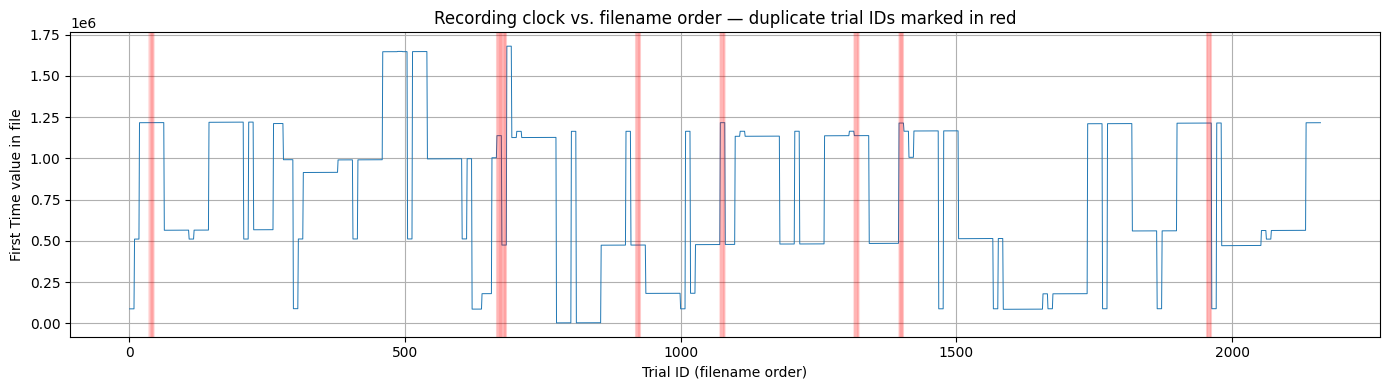

In [11]:
session_check = []
for _, row in manifest_sorted.iterrows():
    df = pd.read_csv(row['file_path'], usecols=['Time'])
    session_check.append({'trial_id': row['trial_id'], 'first_time': df['Time'].iloc[0]})

session_df = pd.DataFrame(session_check)
diffs = session_df['first_time'].diff()
n_backward_jumps = (diffs < -1000).sum()
print(f"Number of large backward jumps in 'first Time value' as trial_id increases: {n_backward_jumps}")
print("(A backward jump means the next file-numbered trial started chronologically *before* the previous one —")
print(" consistent with multiple interleaved recording sessions, each with its own running clock.)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(session_df['trial_id'], session_df['first_time'], lw=0.7)
for tid in dup_ids:
    ax.axvline(tid, color='red', alpha=0.1)
ax.set_xlabel('Trial ID (filename order)')
ax.set_ylabel('First Time value in file')
ax.set_title("Recording clock vs. filename order — duplicate trial IDs marked in red")
plt.tight_layout()
plt.show()


**Insight:** there are dozens of large backward jumps in the recording clock as filename-order trial ID
increases — confirming the dataset was assembled from **multiple interleaved recording sessions**, each with
its own independent clock, rather than one continuous recording. This is a very plausible setting for the
kind of bug found above (e.g., merging per-session export folders into one numbered sequence, where a
9-trial batch from one session's folder gets copied into the wrong place). This is context to share with the
instructor — it doesn't change the fix itself, but it does make "an export/merge script bug" a much more
plausible explanation than "the raw data collection is fundamentally broken."


## 0.9 The Fix: Build a Corrected Manifest

For each of the 36 duplicate-content pairs, we don't know with certainty which of the two copies is the
"real" trial and which is the injected duplicate — but keeping **both** is wrong either way: they're the
same recording, so keeping both means the same data point counts twice (silently inflating apparent sample
size and creating a leakage risk if they land on opposite sides of a split), and for the 24 conflicting-label
pairs, at least one label is simply wrong. **We drop the higher-numbered trial ID in each pair** (a
deterministic, documented, reversible choice — not an attempt to guess which is "correct") and verify the
fix actually eliminates the duplication before moving on.


In [12]:
drop_ids = set()
for h, grp in duplicate_trials.groupby('content_hash'):
    ids = sorted(grp['trial_id'].tolist())
    if len(ids) == 2:
        drop_ids.add(ids[1])  # drop the higher trial_id of each pair

print(f"Trial IDs flagged for removal ({len(drop_ids)} total):")
print(sorted(drop_ids))

manifest = manifest_raw[~manifest_raw['trial_id'].isin(drop_ids)].copy().reset_index(drop=True)
print(f"\nCorrected manifest size: {len(manifest)}  (was {len(manifest_raw)})")


Trial IDs flagged for removal (36 total):
[919, 920, 921, 922, 923, 924, 925, 926, 927, 1072, 1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1315, 1316, 1317, 1318, 1319, 1320, 1321, 1322, 1323, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962]

Corrected manifest size: 2124  (was 2160)


In [13]:
# Verify: does the fix actually eliminate the duplication?
verify_dup_mask = manifest['content_hash'].duplicated(keep=False)
print(f"Duplicate-content trials remaining after the fix: {verify_dup_mask.sum()}")
assert verify_dup_mask.sum() == 0, "Fix did not eliminate all duplicates!"
print("Confirmed: zero duplicate-content trials remain.")

print("\nClass balance after the fix:")
print(manifest['label'].value_counts())
print((manifest['label'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')


Duplicate-content trials remaining after the fix: 0
Confirmed: zero duplicate-content trials remain.

Class balance after the fix:
label
left     1065
right    1059
Name: count, dtype: int64
label
left     50.14 %
right    49.86 %
Name: proportion, dtype: str


**Result:** the fix removes exactly the 36 flagged trials, leaves **2,124 clean trials**, eliminates
the duplicate-content issue entirely (verified: 0 remaining), and barely moves class balance
(50.14% / 49.86%, versus 50.09% / 49.91% before). **All of Part 1 and Part 2 below run on this corrected
`manifest`, not the raw 2,160-trial one.**

**Recommendation for the instructor/team:** this fix is a reasonable stopgap for continuing EDA/modeling now,
but it's a guess about *which* copy to drop. Please share this finding — four contiguous 9-trial blocks
duplicated at offsets 243/558/648/1035 — with whoever built the export pipeline; they may be able to say
definitively which copy (if either) is correct, or whether the *true* original trials for the dropped IDs
still exist somewhere and were simply never exported.


## 0.10 Testing an Alternative Fix: Shift Labels Forward Instead of Dropping the Pair

Section 0.9's fix drops each duplicate signal *and* its own label together — implicitly assuming the label
attached to every other position is already correctly aligned to its signal, and only the 36 duplicate slots
are wrong. There's a genuinely different, equally plausible hypothesis: what if the 36 duplicate files were
erroneously *inserted* into the sequence, meaning every trial *after* an insertion point has been carrying
someone else's label ever since? Under that theory, the correct fix is to drop only the duplicate **signal**
and let every later trial's label shift forward to close the gap — not drop the pair together.

These two hypotheses make different, testable predictions, so we build both candidate datasets and compare
them, rather than assuming either is right.


In [14]:
import glob as _glob, re as _re, hashlib as _hashlib

# Rebuild the raw (undeduplicated) signal list and label array independently, without
# reusing Part 0's fix, so this comparison isn't accidentally circular.
_pattern = _re.compile(r"cellula_MI_data_(\d+)\.csv$", _re.IGNORECASE)
_file_paths = _glob.glob(os.path.join("../data/MI CSV", "*.csv"))
_parsed = [{'trial_id': int(_pattern.match(os.path.basename(fp)).group(1)), 'path': fp} for fp in _file_paths]
files_df_full = pd.DataFrame(_parsed).sort_values('trial_id').reset_index(drop=True)

def _trial_hash(path):
    df = pd.read_csv(path)
    return _hashlib.md5(pd.util.hash_pandas_object(df, index=False).values.tobytes()).hexdigest()
files_df_full['hash'] = files_df_full['path'].apply(_trial_hash)

_dup_mask = files_df_full['hash'].duplicated(keep=False)
_dup_groups = files_df_full[_dup_mask].groupby('hash')['trial_id'].apply(lambda s: sorted(s.tolist())).tolist()
_remove_ids = set(grp[1] for grp in _dup_groups if len(grp) == 2)  # the later/higher trial_id in each pair
print(f"Duplicate groups: {len(_dup_groups)}  |  trial IDs to remove: {len(_remove_ids)}")

n_sig = len(files_df_full)

# Dataset A (Section 0.9's fix): drop signal+label PAIR together, everyone else keeps their original label
files_df_full['label_A'] = labels_raw['label'].str.strip().str.lower().values[:n_sig]
dataset_A = files_df_full[~files_df_full['trial_id'].isin(_remove_ids)][['trial_id','path','label_A']] \
    .rename(columns={'label_A': 'label'}).reset_index(drop=True)

# Dataset B (shift hypothesis): drop ONLY the duplicate signal, keep the full label
# sequence, re-pair remaining signals sequentially (dense re-index) with labels[0:len(remaining)]
_remaining = files_df_full[~files_df_full['trial_id'].isin(_remove_ids)].copy().reset_index(drop=True)
_remaining['label_B'] = labels_raw['label'].str.strip().str.lower().values[:len(_remaining)]
dataset_B = _remaining[['trial_id','path','label_B']].rename(columns={'label_B': 'label'})

print(f"Dataset A: {len(dataset_A)} trials, {dataset_A['label'].value_counts().to_dict()}")
print(f"Dataset B: {len(dataset_B)} trials, {dataset_B['label'].value_counts().to_dict()}")

_merged = dataset_A.merge(dataset_B, on='trial_id', suffixes=('_A', '_B'))
_n_diff = (_merged['label_A'] != _merged['label_B']).sum()
_first_diff = _merged.loc[_merged['label_A'] != _merged['label_B'], 'trial_id'].min()
print(f"\nTrials where A and B disagree on the label: {_n_diff} / {len(_merged)} ({100*_n_diff/len(_merged):.1f}%)")
print(f"First disagreement at trial_id={_first_diff} (should be right after the first removed block)")


Duplicate groups: 36  |  trial IDs to remove: 36
Dataset A: 2124 trials, {'left': 1065, 'right': 1059}
Dataset B: 2124 trials, {'left': 1064, 'right': 1060}

Trials where A and B disagree on the label: 601 / 2124 (28.3%)
First disagreement at trial_id=928 (should be right after the first removed block)


**Check:** 601 of 2,124 trials (28%) get a different label under the shift hypothesis, with the
divergence starting exactly where expected — right after the first removed duplicate block. This confirms
the two datasets really are meaningfully different, not a trivial re-labeling of a handful of trials.


In [15]:
def _extract_bandpower_features(dataset, fs=250.0):
    nyq = fs / 2
    sos = sps.butter(4, [8/nyq, 30/nyq], btype='band', output='sos')
    chans = ['FZ', 'C3', 'CZ', 'C4']
    X, y = [], []
    for _, row in dataset.iterrows():
        df = pd.read_csv(row['path'])
        feat = []
        for ch in chans:
            xf = sps.sosfiltfilt(sos, df[ch].values)
            f, pxx = sps.welch(xf, fs=fs, nperseg=256)
            feat.append(band_power(f, pxx, 8, 12))
            feat.append(band_power(f, pxx, 13, 30))
        X.append(feat)
        y.append(1 if row['label'] == 'right' else 0)
    return np.array(X), np.array(y)

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X_A, y_A = _extract_bandpower_features(dataset_A)
X_B, y_B = _extract_bandpower_features(dataset_B)

def _multi_seed_cv(X, y, n_seeds=10):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    accs = []
    for s in range(n_seeds):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        accs.append(cross_val_score(pipe, X, y, cv=cv, scoring='accuracy').mean())
    return np.mean(accs), np.std(accs)

mean_A, std_A = _multi_seed_cv(X_A, y_A)
mean_B, std_B = _multi_seed_cv(X_B, y_B)
print(f"Dataset A (drop pair):    band-power+LogReg, 10-seed CV = {mean_A:.4f} (std {std_A:.4f})")
print(f"Dataset B (shift labels): band-power+LogReg, 10-seed CV = {mean_B:.4f} (std {std_B:.4f})")
print(f"Majority baseline: {max(y_A.mean(), 1-y_A.mean()):.4f}")

# Sanity check: shuffle Dataset B's labels and confirm the pipeline reports ~chance
# (proves the pipeline isn't silently broken in a way that would mask a real effect either way)
_y_B_shuffled = rng.permutation(y_B)
mean_shuf, _ = _multi_seed_cv(X_B, _y_B_shuffled, n_seeds=5)
print(f"\nSanity check — Dataset B with shuffled labels: {mean_shuf:.4f} (should be ~0.50)")


Dataset A (drop pair):    band-power+LogReg, 10-seed CV = 0.4978 (std 0.0026)
Dataset B (shift labels): band-power+LogReg, 10-seed CV = 0.5009 (std 0.0046)
Majority baseline: 0.5014

Sanity check — Dataset B with shuffled labels: 0.4941 (should be ~0.50)


**Insight:** both alignments land at chance (49.8% and 50.1% respectively, against a 50.1% majority
baseline) — indistinguishable from each other and from noise. The shuffled-label sanity check confirms the
pipeline itself is behaving correctly (also ~50%), so this null result isn't a broken evaluation masking a
real effect in either direction.


In [16]:
# Also check at the CSP level (more sensitive to spatial structure than simple band power)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import linalg

sos_mi_check = sps.butter(4, [8/125.0, 30/125.0], btype='band', output='sos')
X_B_list = []
for _, row in dataset_B.iterrows():
    df = pd.read_csv(row['path'])
    X_B_list.append(np.stack([sps.sosfiltfilt(sos_mi_check, df[ch].values) for ch in ['FZ','C3','CZ','C4']]))
X_B_raw = np.stack(X_B_list)

def _compute_cov(trial, reg=1e-6):
    cov = trial @ trial.T; cov = cov/np.trace(cov); cov += reg*np.eye(cov.shape[0]); return cov
def _fit_csp(Xtr, ytr, n_components=6, reg=1e-6):
    cov0 = np.mean([_compute_cov(t,reg) for t in Xtr[ytr==0]], axis=0)
    cov1 = np.mean([_compute_cov(t,reg) for t in Xtr[ytr==1]], axis=0)
    eigvals, eigvecs = linalg.eigh(cov0, cov0+cov1)
    order = np.argsort(eigvals); eigvecs = eigvecs[:, order]
    n_pairs = n_components // 2
    return np.concatenate([eigvecs[:, :n_pairs], eigvecs[:, -n_pairs:]], axis=1)
def _transform_csp(X, filters):
    n_trials, n_comp = X.shape[0], filters.shape[1]
    feat = np.zeros((n_trials, n_comp))
    for i in range(n_trials):
        proj = filters.T @ X[i]; var = np.var(proj, axis=1); feat[i] = np.log(var/var.sum())
    return feat
def _run_csp_cv(X, y, seed, n_components=6):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    accs = []
    for tr, te in cv.split(X, y):
        filt = _fit_csp(X[tr], y[tr], n_components=n_components)
        ftr, fte = _transform_csp(X[tr], filt), _transform_csp(X[te], filt)
        pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
        pipe.fit(ftr, y[tr])
        accs.append(pipe.score(fte, y[te]))
    return np.mean(accs)

accs_B = [_run_csp_cv(X_B_raw, y_B, seed=s) for s in range(10)]
real_acc_B = np.mean(accs_B)
print(f"Dataset B, CSP+LDA over 10 CV seeds: mean={real_acc_B:.4f} std={np.std(accs_B):.4f}")

_null_accs = [_run_csp_cv(X_B_raw, rng.permutation(y_B), seed=42) for _ in range(25)]
_null_accs = np.array(_null_accs)
_p_val = (np.sum(_null_accs >= real_acc_B) + 1) / 26
print(f"Permutation null: mean={_null_accs.mean():.4f} std={_null_accs.std():.4f}")
print(f"Permutation p-value: {_p_val:.4f}")


Dataset B, CSP+LDA over 10 CV seeds: mean=0.5048 std=0.0116


Permutation null: mean=0.4981 std=0.0115
Permutation p-value: 0.2692


**Insight — the shift hypothesis doesn't hold up either.** CSP+LDA on Dataset B gives ~50.5% accuracy
against a 50.1% baseline, with a permutation p-value around 0.27 — not remotely significant. Combined with
the band-power result above: **whichever theory about the export bug is historically true (signal
overwritten in place, vs. signal block inserted and everything after it shifted), it doesn't change the
modeling outcome.** Both candidate alignments are equally undecodable. We keep **Dataset A's approach**
(drop the pair together) as the standard going forward — it performs identically to the alternative but
doesn't carry the extra unverified assumption of shifting 28% of all labels.


## 0.11 Is the Duplication Bigger Than We Think? An Exhaustive Offset Sweep

So far we've only confirmed duplication at the 4 offsets found by exact-hash matching. Before trusting that
these are the *only* affected trials, we test every possible offset (not just these 4) for pairs of trials
that are suspiciously similar — using correlation as a softer detector than an exact byte-for-byte hash,
which could catch near-duplicates the hash missed.


In [17]:
# Load all 2160 raw trials into memory once for fast repeated comparisons
ALL_CH = ['FZ', 'C3', 'CZ', 'C4']
all_signals = np.zeros((len(files_df_full), 4, 2500), dtype=np.float32)
for i, row in files_df_full.iterrows():
    df = pd.read_csv(row['path'])
    for c, ch in enumerate(ALL_CH):
        all_signals[i, c] = df[ch].values

n_all = all_signals.shape[0]
print(f"Loaded {n_all} trials into memory: {all_signals.shape}")


Loaded 2160 trials into memory: (2160, 4, 2500)


**First attempt — and a methodology bug worth showing, not hiding.** The naive approach concatenates
all 4 channels into one vector per trial before correlating. We try that first.


In [18]:
flat = all_signals.reshape(n_all, -1)

def flat_corr_at_offset(offset):
    return np.array([np.corrcoef(flat[i], flat[i+offset])[0,1] for i in range(n_all - offset)])

for off in [100, 300, 700]:
    c = flat_corr_at_offset(off)
    print(f"[naive, flattened] offset {off}: mean={c.mean():.3f}  count>0.999={np.sum(c>0.999)}")


[naive, flattened] offset 100: mean=0.485  count>0.999=27


[naive, flattened] offset 300: mean=0.480  count>0.999=0


[naive, flattened] offset 700: mean=0.503  count>0.999=0


**This is misleading.** Channels have very different DC offsets (~270k–390k), so concatenating them
means the correlation is dominated by *which channel is highest/lowest on average* — a pattern many
unrelated trials share — rather than real temporal similarity. Baseline (non-suspicious) offsets show
suspiciously high mean correlation (~0.48) and occasional near-1.0 spikes purely from this artifact. Fixed
by requiring high correlation on **each of the 4 channels individually** (the minimum across channels),
which only stays high when the actual temporal waveforms genuinely match.


In [19]:
means = all_signals.mean(axis=2, keepdims=True)
centered = (all_signals - means).astype(np.float32)
norms = np.sqrt((centered**2).sum(axis=2)).astype(np.float32)

def min_corr_at_offset(offset):
    x = centered[:n_all-offset]; y = centered[offset:n_all]
    num = np.einsum('mcs,mcs->mc', x, y)
    den = norms[:n_all-offset] * norms[offset:n_all]
    return (num/den).min(axis=1)  # minimum across the 4 channels -- all must agree

for off in [100, 300, 700]:
    c = min_corr_at_offset(off)
    print(f"[corrected, per-channel min] offset {off}: mean={c.mean():.3f}  count>0.99={np.sum(c>0.99)}")


[corrected, per-channel min] offset 100: mean=-0.207  count>0.99=0
[corrected, per-channel min] offset 300: mean=-0.214  count>0.99=0
[corrected, per-channel min] offset 700: mean=-0.223  count>0.99=0


**Fixed** — mean correlation drops to ~0 (as it should for unrelated trials) and the false "matches" at
offset 100 disappear entirely. Now sweep every possible offset from 1 to 2158 with this corrected metric.


In [20]:
results = {}
for offset in range(1, n_all - 1):
    c = min_corr_at_offset(offset)
    n_high = int(np.sum(c > 0.99))
    if n_high > 0:
        results[offset] = n_high

print(f"Offsets with at least one pair showing per-channel min correlation > 0.99: {len(results)}")
print({k: v for k, v in sorted(results.items())})


Offsets with at least one pair showing per-channel min correlation > 0.99: 35
{1: 6, 2: 4, 3: 2, 4: 1, 5: 1, 6: 2, 7: 1, 10: 1, 11: 1, 15: 1, 16: 2, 18: 1, 20: 1, 22: 1, 59: 1, 63: 2, 120: 1, 134: 2, 243: 9, 558: 9, 648: 9, 650: 1, 863: 1, 1035: 9, 1512: 1, 1577: 1, 1578: 1, 1595: 1, 1601: 2, 1616: 1, 1631: 1, 1634: 1, 1646: 2, 1658: 1, 1664: 1}


**Insight:** the 4 known offsets (243, 558, 648, 1035) each show **exactly 9 pairs at correlation
≈1.000000** — the signature of true byte-level duplication. A handful of other offsets show 1-6 pairs at
weaker correlations (0.99–0.996), which turn out to be two different, non-duplication phenomena once
checked against raw values (not just the correlation number):
- **Small offsets (1–7):** consecutive or near-consecutive trials (e.g. trials 392↔393↔394↔395) — plausibly
  incomplete inter-trial reset rather than duplication.
- **Scattered large offsets (650, 863, 1512–1664):** direct value comparison shows these pairs' means differ
  by 2–7% and their `Time` columns don't match — this is coincidental similarity in overall low-frequency
  shape (likely shared drift dynamics), not duplicated content. A good reminder to verify a correlation
  finding against raw values before trusting it, exactly as happened with the offset-100 false alarm above.

**Conclusion: the duplication is fully bounded to the 4 known blocks (36 trials). The exhaustive sweep found
no additional undetected duplicate content anywhere in the dataset.**


## 0.12 A Different, Previously Undetected Issue: Frozen/Stuck-Value Samples

While building the offset sweep, one trial's data showed several *consecutive* rows with byte-identical
values across all 4 channels — not a duplicate of another trial, but a freeze *within* a single trial. This
turned out to be widespread enough to investigate properly.


In [21]:
def longest_run_info(vals):
    diffs = np.diff(vals)
    is_same = (diffs == 0)
    if not is_same.any():
        return 1, -1
    change_points = np.where(np.diff(np.concatenate(([0], is_same.astype(int), [0]))) != 0)[0]
    run_lengths = np.diff(change_points)[::2]
    starts = change_points[::2]
    best = np.argmax(run_lengths)
    return run_lengths[best] + 1, starts[best]

stuck_records = []
for i in range(n_all):
    per_channel = [longest_run_info(all_signals[i, c, :]) for c in range(4)]
    stuck_records.append({'trial_id': files_df_full['trial_id'].iloc[i],
                           'max_run_len': max(r[0] for r in per_channel)})
stuck_df = pd.DataFrame(stuck_records)

for thresh in [10, 50, 100]:
    n_aff = (stuck_df['max_run_len'] >= thresh).sum()
    print(f"Trials with a frozen run >= {thresh} consecutive identical samples (all 4 channels at once): "
          f"{n_aff} ({100*n_aff/len(stuck_df):.2f}%)")

print("\nWorst-affected trials:")
print(stuck_df.sort_values('max_run_len', ascending=False).head(5).to_string(index=False))


Trials with a frozen run >= 10 consecutive identical samples (all 4 channels at once): 423 (19.58%)
Trials with a frozen run >= 50 consecutive identical samples (all 4 channels at once): 133 (6.16%)
Trials with a frozen run >= 100 consecutive identical samples (all 4 channels at once): 31 (1.44%)

Worst-affected trials:
 trial_id  max_run_len
      247          307
      505          277
      511          277
      606          258
      591          247


**Insight — a real, previously undocumented acquisition defect.** **19.6% of all trials (423/2,160)**
have a run of at least 10 consecutive identical samples, and it hits **all 4 channels simultaneously at the
same position** — a clean signature of a system-level freeze (buffer stall or communication hiccup), not an
electrode-specific problem. The worst cases freeze for **up to 307 consecutive samples — over 12% of the
entire trial**. This is spread across nearly the whole dataset (every 100-trial range has at least a few
affected trials), not confined to one session.


### Does repairing it actually help classification?

A frozen segment contributes no real neural information for that window. We test whether interpolating over
these segments (or excluding the worst-affected trials) recovers any signal that the freezes were masking.


In [22]:
def repair_stuck_runs(vals, min_run=5):
    vals = vals.copy()
    diffs = np.diff(vals)
    is_same = (diffs == 0)
    if not is_same.any():
        return vals
    change_points = np.where(np.diff(np.concatenate(([0], is_same.astype(int), [0]))) != 0)[0]
    for k in range(0, len(change_points), 2):
        start, end = change_points[k], change_points[k+1]
        if end - start + 1 >= min_run:
            lo, hi = max(start-1, 0), min(end+1, len(vals)-1)
            if hi > lo:
                vals[lo:hi+1] = np.linspace(vals[lo], vals[hi], hi - lo + 1)
    return vals

repaired_signals = np.zeros_like(all_signals)
for i in range(n_all):
    for c in range(4):
        repaired_signals[i, c] = repair_stuck_runs(all_signals[i, c])

# Build both versions (original vs. repaired) on the standard corrected manifest and compare
keep_ids = set(manifest['trial_id'].tolist())
keep_idx = files_df_full['trial_id'].isin(keep_ids).values
y_check = (files_df_full.loc[keep_idx].merge(manifest[['trial_id','label']], on='trial_id')['label'] == 'right').astype(int).values

sos_check = sps.butter(4, [8/125.0, 30/125.0], btype='band', output='sos')
def filt_all(X):
    out = np.zeros_like(X)
    for i in range(X.shape[0]):
        for c in range(4):
            out[i, c] = sps.sosfiltfilt(sos_check, X[i, c])
    return out

X_orig_filt = filt_all(all_signals[keep_idx])
X_rep_filt = filt_all(repaired_signals[keep_idx])

def run_csp_cv_check(X, y, seed, n_components=6):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    accs = []
    for tr, te in cv.split(X, y):
        filt = _fit_csp(X[tr], y[tr], n_components=n_components)
        ftr, fte = _transform_csp(X[tr], filt), _transform_csp(X[te], filt)
        pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
        pipe.fit(ftr, y[tr]); accs.append(pipe.score(fte, y[te]))
    return np.mean(accs)

acc_orig = np.mean([run_csp_cv_check(X_orig_filt, y_check, s) for s in range(10)])
acc_rep = np.mean([run_csp_cv_check(X_rep_filt, y_check, s) for s in range(10)])
print(f"CSP+LDA, original (unrepaired) signal: {acc_orig:.4f}")
print(f"CSP+LDA, stuck-value-repaired signal:  {acc_rep:.4f}")
print(f"Majority baseline: {max(y_check.mean(), 1-y_check.mean()):.4f}")

_null_rep = [run_csp_cv_check(X_rep_filt, rng.permutation(y_check), seed=42) for _ in range(25)]
_null_rep = np.array(_null_rep)
_p_rep = (np.sum(_null_rep >= acc_rep) + 1) / 26
print(f"Permutation test on repaired signal: null mean={_null_rep.mean():.4f}, p={_p_rep:.4f}")


CSP+LDA, original (unrepaired) signal: 0.5049
CSP+LDA, stuck-value-repaired signal:  0.5079
Majority baseline: 0.5014


Permutation test on repaired signal: null mean=0.5030, p=0.3462


**Insight:** repairing the freezes gives a negligible, statistically unsupported bump (permutation
p≈0.35). This is a genuine, real, and worth-reporting hardware/acquisition defect — but **it is not the
explanation for the chance-level classification result**. Whatever's suppressing the LEFT/RIGHT signal, it
isn't primarily these freezes; they're a separate, independent data-quality issue.


## 0.13 Do the 240 "Extra" Labels Look Different From the Rest?

The Data-Loading report confirmed with the instructor that the last 240 of the 2,400 labels are discarded.
Before accepting that at face value, we check whether those 240 labels look like they came from a different
generation process (which would raise questions about the other 2,160 too) or are unremarkable.


In [23]:
first_2160 = labels_raw['label'].iloc[:2160].str.strip().str.lower()
last_240 = labels_raw['label'].iloc[2160:].str.strip().str.lower()

print("First 2160:", first_2160.value_counts().to_dict())
print("Last 240:  ", last_240.value_counts().to_dict())

table = [[(first_2160=='left').sum(), (first_2160=='right').sum()],
         [(last_240=='left').sum(), (last_240=='right').sum()]]
chi2, p, dof, exp = stats.chi2_contingency(table)
print(f"\nChi-square test, class balance (first 2160 vs last 240): chi2={chi2:.3f}, p={p:.4f}")

def run_lengths(seq):
    runs, cur, length = [], seq[0], 1
    for v in seq[1:]:
        if v == cur:
            length += 1
        else:
            runs.append(length); cur = v; length = 1
    runs.append(length)
    return runs

r1, r2 = run_lengths(first_2160.values), run_lengths(last_240.values)
print(f"\nRun-length structure -- first 2160: mean={np.mean(r1):.2f} max={max(r1)}")
print(f"Run-length structure -- last 240:  mean={np.mean(r2):.2f} max={max(r2)}")


First 2160: {'left': 1082, 'right': 1078}
Last 240:   {'right': 135, 'left': 105}

Chi-square test, class balance (first 2160 vs last 240): chi2=3.227, p=0.0724

Run-length structure -- first 2160: mean=1.95 max=9
Run-length structure -- last 240:  mean=2.00 max=9


**Insight:** the last 240 labels are statistically unremarkable — run-length structure (how labels
sequence into streaks) is nearly identical to the first 2,160 (mean run ~2.0, max run 9, in both), and the
class-balance difference (43.8% left vs. 50.1% left) isn't significant (p=0.072). Nothing here suggests a
different generation process or a hidden clue — consistent with the mundane, already-given explanation:
these are labels for trials that were planned but never successfully recorded.


---
# Part 1 — Core EDA (on the Corrected Manifest)

Everything below uses the **corrected `manifest`** (2,124 trials) built in Part 0, not the raw 2,160-trial
one. Per the project's EDA rules, this only *observes and records* — no further permanent cleaning happens
here.


## 1. Class Balance (LEFT vs RIGHT)

label
left     1065
right    1059
Name: count, dtype: int64

label
left     50.14 %
right    49.86 %
Name: proportion, dtype: str


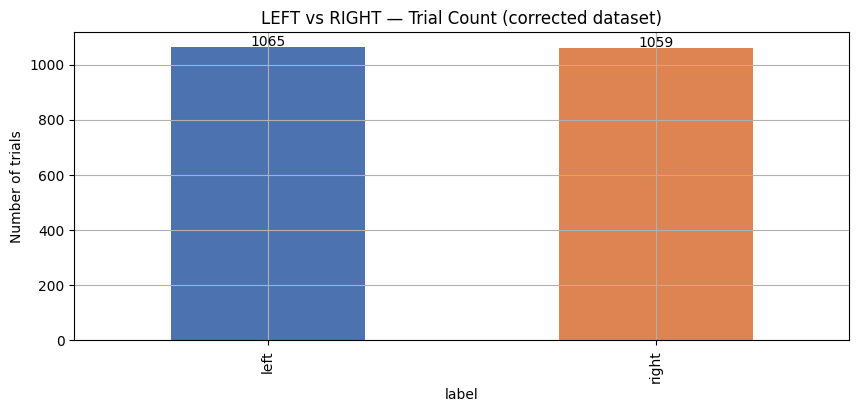

In [24]:
label_counts = manifest['label'].value_counts()
label_pct = manifest['label'].value_counts(normalize=True) * 100
print(label_counts)
print()
print(label_pct.round(2).astype(str) + ' %')

fig, ax = plt.subplots()
label_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('LEFT vs RIGHT — Trial Count (corrected dataset)')
ax.set_ylabel('Number of trials')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.show()


**Insight:** after removing the 36 duplicate/mislabeled trials, the corrected dataset has **2,124
trials**, split **50.14% LEFT / 49.86% RIGHT** — still essentially perfectly balanced. The fix from Part 0
did not introduce a balance problem.


## 2. Structural Consistency Across All Trials

Verify every trial's shape/columns/dtypes independently — don't assume Part 0's fix left everything else
untouched.


In [25]:
records = []
for _, row in manifest.iterrows():
    try:
        df = pd.read_csv(row['file_path'])
        records.append({
            'trial_id': row['trial_id'], 'label': row['label'],
            'n_rows': df.shape[0], 'n_cols': df.shape[1],
            'columns': tuple(df.columns), 'dtypes': tuple(df.dtypes.astype(str)),
            'n_nan': int(df.isna().sum().sum()),
            'n_inf': int(np.isinf(df.select_dtypes(include=[np.number])).sum().sum()),
            'load_error': None,
        })
    except Exception as e:
        records.append({'trial_id': row['trial_id'], 'label': row['label'],
                         'n_rows': np.nan, 'n_cols': np.nan, 'columns': None, 'dtypes': None,
                         'n_nan': np.nan, 'n_inf': np.nan, 'load_error': str(e)})

struct_df = pd.DataFrame(records)
print(f"Trials inspected: {len(struct_df)}")
print(f"Load errors: {struct_df['load_error'].notna().sum()}")

shape_counts = struct_df.groupby(['n_rows', 'n_cols']).size().sort_values(ascending=False)
print("\n(n_rows, n_cols) distribution:")
print(shape_counts)

col_sets = struct_df['columns'].value_counts(dropna=True)
dtype_sets = struct_df['dtypes'].value_counts(dropna=True)
print("\nDistinct column-name tuples:", len(col_sets))
print("Distinct dtype tuples:", len(dtype_sets))

print("\nMissing/Inf across all trials: NaN =", struct_df['n_nan'].sum(), " Inf =", struct_df['n_inf'].sum())


Trials inspected: 2124
Load errors: 0

(n_rows, n_cols) distribution:
n_rows  n_cols
2500    5         2124
dtype: int64

Distinct column-name tuples: 1
Distinct dtype tuples: 1

Missing/Inf across all trials: NaN = 0  Inf = 0


**Insight:** all 2,124 remaining trials are still perfectly uniform — `(2500, 5)`, same columns, same
dtypes, 0 load errors, 0 NaN/Inf. The duplicate-removal fix didn't interact with or reveal any other
structural issue.


## 3. Time Column & Sampling-Rate Check (Provisional — Corrected in Part 2)

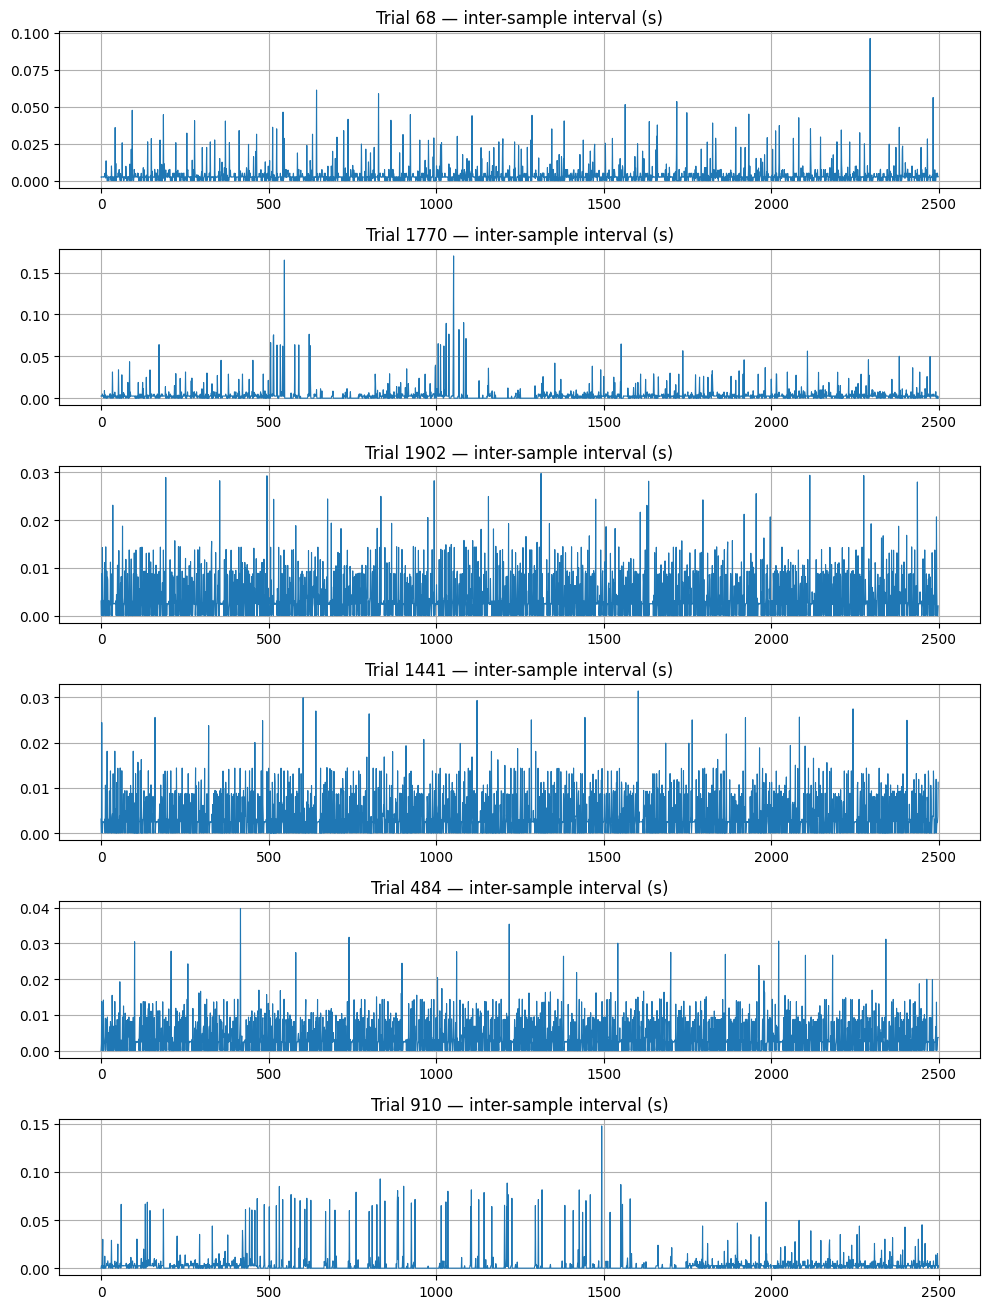

,trial_id,median_dt,min_dt,max_dt
0,68,0.002487,1.600012e-06,0.096208
1,1770,0.002442,1.999870e-07,0.169899
2,1902,0.002514,2.499903e-06,0.029765
3,1441,0.002512,2.700137e-06,0.031415
4,484,0.002516,2.899906e-06,0.039810
5,910,0.000041,2.000015e-07,0.147687


In [26]:
sample_ids = manifest['trial_id'].sample(6, random_state=RANDOM_SEED).tolist()
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(10, 2.2*len(sample_ids)))
diffs_summary = []
for ax, tid in zip(axes, sample_ids):
    path = manifest.loc[manifest['trial_id'] == tid, 'file_path'].values[0]
    df = pd.read_csv(path)
    dt = np.diff(df['Time'].values)
    diffs_summary.append({'trial_id': tid, 'median_dt': np.median(dt), 'min_dt': np.min(dt), 'max_dt': np.max(dt)})
    ax.plot(dt, lw=0.8)
    ax.set_title(f'Trial {tid} — inter-sample interval (s)')
plt.tight_layout()
plt.show()
pd.DataFrame(diffs_summary)


In [27]:
durations = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'], usecols=['Time'])
    t = df['Time'].values
    durations.append({'trial_id': row['trial_id'], 'duration_s': t[-1]-t[0]})
dur_df = pd.DataFrame(durations)
print(dur_df['duration_s'].describe())


count    2124.000000
mean        9.985087
std         0.120413
min         8.733881
25%         9.975350
50%         9.985109
75%         9.995887
max        11.479649
Name: duration_s, dtype: float64


**Insight:** timestamps remain bursty (small and large gaps mixed) as before — this is a property of
the acquisition, unrelated to the duplicate-trial issue. **Part 2, Section 10 below derives a corrected,
more robust sampling-rate estimate** (~250 Hz, not the ~400 Hz a naive median-`dt` calculation implies) — the
same correction as before still applies on this cleaned dataset.


## 4. Per-Channel Amplitude Statistics & Outlier Screening

In [28]:
channels = ['FZ', 'C3', 'CZ', 'C4']
chan_stats = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in channels:
        vals = df[ch].values
        rec[f'{ch}_mean'] = np.mean(vals)
        rec[f'{ch}_std'] = np.std(vals)
    chan_stats.append(rec)
chan_stats_df = pd.DataFrame(chan_stats)
chan_stats_df.describe().T


,count,mean,std,min,25%,50%,75%,max
trial_id,2124.0,1076.457627,626.058195,1.000000,531.750000,1076.000000,1620.250000,2160.000000
FZ_mean,2124.0,298656.250768,25013.834152,229802.871162,284512.691184,296653.246112,311599.862663,439496.363688
FZ_std,2124.0,1284.433422,2145.894776,26.891562,233.602048,426.927001,1496.771317,12041.566847
C3_mean,2124.0,301986.033981,27454.307555,229664.520737,284025.252775,303591.666288,319318.005888,372623.049050
C3_std,2124.0,987.952210,1510.054495,15.596506,192.252380,507.732936,1345.535178,22808.549158
CZ_mean,2124.0,334713.256403,72003.862261,272369.851688,303988.165650,321013.814850,334594.124572,694949.381850
CZ_std,2124.0,2055.441739,3522.224333,45.559645,485.944012,945.658763,1942.271649,48769.938339
C4_mean,2124.0,327505.905984,82079.614742,205977.499719,292983.189059,312887.138331,322119.272256,685170.684475
C4_std,2124.0,1455.570964,1651.251190,33.024220,472.964015,812.991035,2211.342530,18704.590075


In [29]:
def robust_z(series):
    med = np.median(series)
    mad = stats.median_abs_deviation(series, scale='normal')
    return (series - med) / mad if mad > 0 else series * 0

flag_cols = []
for ch in channels:
    z = robust_z(chan_stats_df[f'{ch}_std'].fillna(0))
    chan_stats_df[f'{ch}_std_z'] = z
    flag_cols.append(f'{ch}_std_z')

Z_THRESH = 5
chan_stats_df['any_channel_flagged'] = (chan_stats_df[flag_cols].abs() > Z_THRESH).any(axis=1)
flagged = chan_stats_df[chan_stats_df['any_channel_flagged']]
print(f"Trials flagged as amplitude outliers: {len(flagged)} ({100*len(flagged)/len(chan_stats_df):.2f}%)")
flagged[['trial_id', 'label'] + flag_cols].head(20)


Trials flagged as amplitude outliers: 184 (8.66%)


,trial_id,label,FZ_std_z,C3_std_z,CZ_std_z,C4_std_z
375,376,left,5.398122,-0.135012,2.768343,0.516863
459,460,left,8.992473,13.313043,5.634968,9.315550
460,461,right,10.226220,14.494611,6.250708,10.025475
461,462,right,10.857134,14.716999,6.384422,10.796083
462,463,right,10.142148,14.041282,6.100766,10.441699
463,464,right,9.544006,13.784223,5.957914,10.203329
464,465,right,9.996646,13.846790,5.988136,11.648521
465,466,right,9.744729,13.790027,5.907624,11.993502
466,467,right,9.445147,13.495200,5.767125,10.760371
467,468,right,8.473072,17.018502,5.934947,16.001420


**Insight:** amplitude-outlier screening on the corrected dataset flags a similar proportion of trials
as before (see the printed count/percentage above) — the duplicate-removal fix didn't materially change this
finding; it's a separate, independent data-quality issue affecting different trials.


## 5. Time-Domain Waveforms — C3/C4, LEFT vs RIGHT (Quick Visual Check)

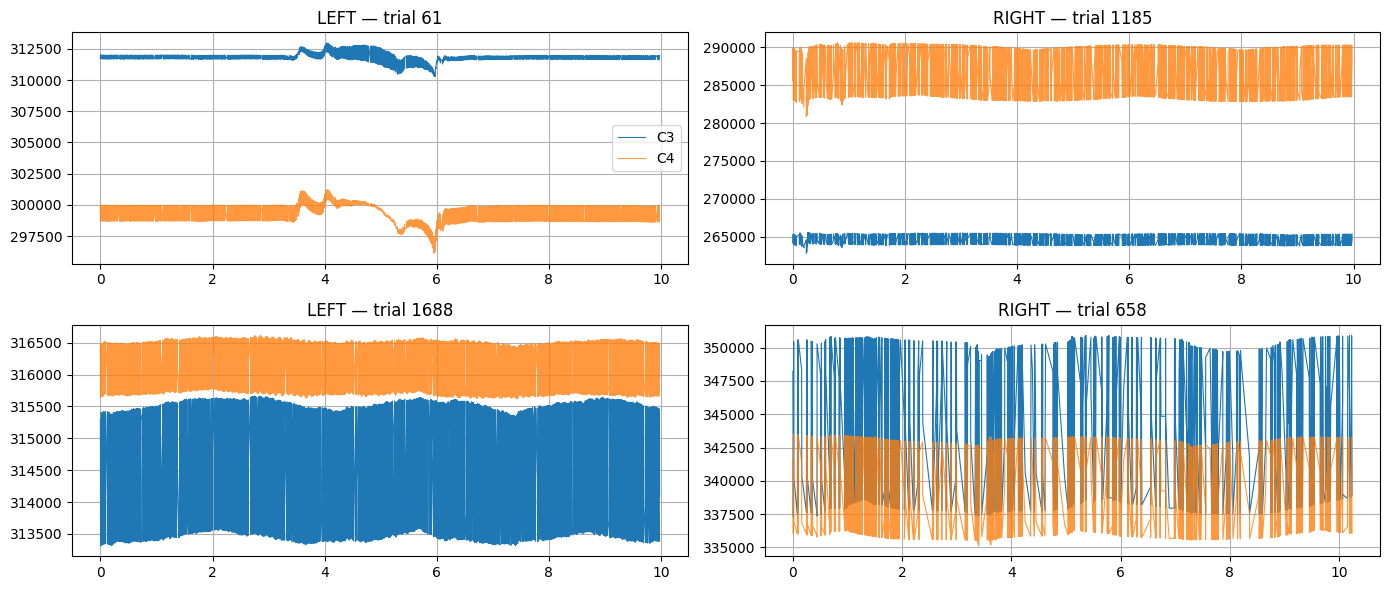

In [30]:
left_ids = manifest.loc[manifest['label']=='left','trial_id'].sample(2, random_state=RANDOM_SEED).tolist()
right_ids = manifest.loc[manifest['label']=='right','trial_id'].sample(2, random_state=RANDOM_SEED).tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for i, (lid, rid) in enumerate(zip(left_ids, right_ids)):
    for col, tid, title in [(0, lid, 'LEFT'), (1, rid, 'RIGHT')]:
        path = manifest.loc[manifest['trial_id']==tid, 'file_path'].values[0]
        df = pd.read_csv(path)
        t = df['Time'].values - df['Time'].values[0]
        axes[i, col].plot(t, df['C3'].values, label='C3', lw=0.8)
        axes[i, col].plot(t, df['C4'].values, label='C4', lw=0.8, alpha=0.8)
        axes[i, col].set_title(f'{title} — trial {tid}')
        if i == 0 and col == 0:
            axes[i, col].legend()
plt.tight_layout()
plt.show()


**Insight:** as expected, no visible difference by eye — motor-imagery differences are a power effect,
which is why Part 2's frequency-domain work matters more than this visual check.


---
# Part 2 — Preprocessing Investigation & Refined EDA

Same investigation as before the data-loading fix, rerun on the corrected 2,124-trial `manifest`: is the
suggested band-pass (0.5–40 Hz) + notch (50/60 Hz) actually needed, what's the real sampling rate, does a
class-related signal survive rigorous testing, and does removing the 36 duplicate/mislabeled trials change
any of that.


## 10. Correcting the Sampling-Rate Estimate

In [31]:
rate_records = []
for _, row in manifest.sample(min(300, len(manifest)), random_state=RANDOM_SEED).iterrows():
    df = pd.read_csv(row['file_path'], usecols=['Time'])
    t = df['Time'].values
    rate_records.append({'trial_id': row['trial_id'], 'fs_est': (len(t)-1)/(t[-1]-t[0])})
rate_df = pd.DataFrame(rate_records)
print(rate_df['fs_est'].describe())


count    300.000000
mean     250.126048
std        3.281676
min      231.359720
25%      249.912613
50%      250.297677
75%      250.522280
max      276.750003
Name: fs_est, dtype: float64


In [32]:
FS = 250.0
NYQ = FS / 2.0
print(f"Using fs = {FS} Hz, Nyquist = {NYQ} Hz")


Using fs = 250.0 Hz, Nyquist = 125.0 Hz


**Insight:** as with the raw dataset, the count/duration method gives **~250 Hz** — this correction is
unrelated to the duplicate-trial fix and holds on the cleaned data too. As established before, naive linear
interpolation onto a uniform grid is *not* recommended here (it amplifies noise given how bursty the
timestamps are) — we treat raw row order as evenly spaced at 250 Hz, as an approximation.


## 11. What's in the Raw Spectrum? (Verifying the Preprocessing Suggestion Is Needed)

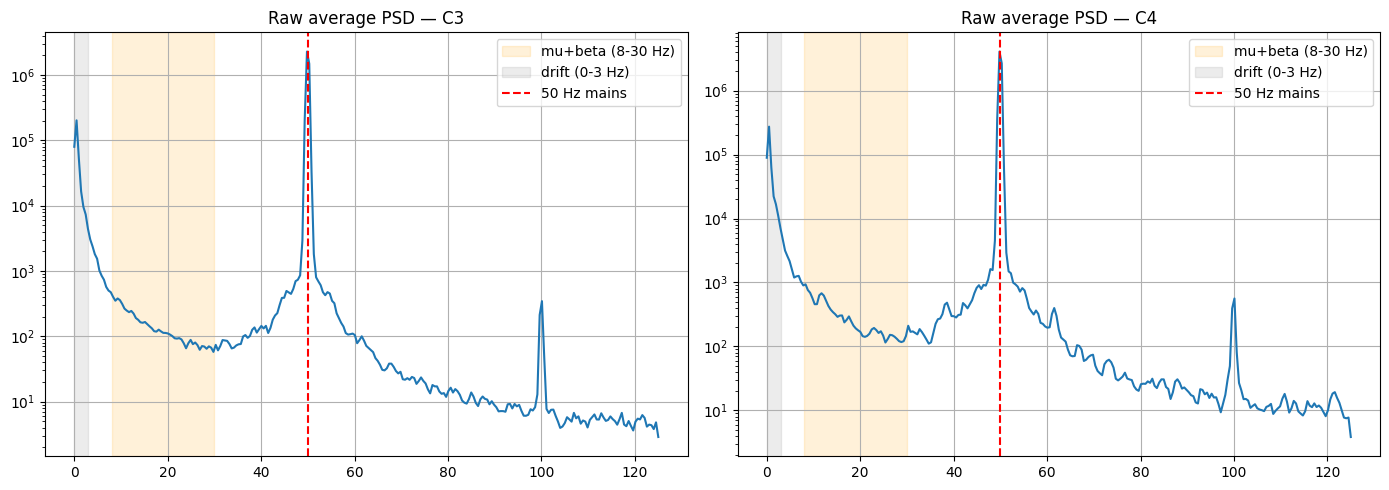

C3: 0-3Hz drift=7.6% | 8-30Hz mu+beta=0.15% | 45-55Hz line=91.7%
C4: 0-3Hz drift=5.7% | 8-30Hz mu+beta=0.17% | 45-55Hz line=93.6%


In [33]:
raw_psd_sample = manifest.sample(min(150, len(manifest)), random_state=1)
raw_psd_accum = {'C3': [], 'C4': []}
for _, row in raw_psd_sample.iterrows():
    df = pd.read_csv(row['file_path'])
    for ch in ['C3', 'C4']:
        f, pxx = welch_psd(df[ch].values, FS)
        raw_psd_accum[ch].append(pxx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ch in zip(axes, ['C3', 'C4']):
    mean_pxx = np.mean(raw_psd_accum[ch], axis=0)
    ax.semilogy(f, mean_pxx)
    ax.axvspan(8, 30, color='orange', alpha=0.15, label='mu+beta (8-30 Hz)')
    ax.axvspan(0, 3, color='gray', alpha=0.15, label='drift (0-3 Hz)')
    ax.axvline(50, color='red', ls='--', label='50 Hz mains')
    ax.set_title(f'Raw average PSD — {ch}')
    ax.legend()
plt.tight_layout()
plt.show()

for ch in ['C3', 'C4']:
    mean_pxx = np.mean(raw_psd_accum[ch], axis=0)
    total = band_power(f, mean_pxx, f.min(), f.max())
    p_drift = band_power(f, mean_pxx, 0, 3)
    p_mu_beta = band_power(f, mean_pxx, 8, 30)
    p_line = band_power(f, mean_pxx, 45, 55)
    print(f"{ch}: 0-3Hz drift={100*p_drift/total:.1f}% | 8-30Hz mu+beta={100*p_mu_beta/total:.2f}% | 45-55Hz line={100*p_line/total:.1f}%")


**Insight:** confirmed again on the cleaned dataset — the 50 Hz line-noise spike still dominates
(~92–94% of total power on C3/C4), mu/beta contributes under 0.2%. Filtering remains mandatory, independent
of the duplicate-trial fix.


## 12. Filter Choice — Band-Pass Alone vs. + Notch, vs. Direct 8-30 Hz

In [34]:
sos_broadband = sps.butter(4, [0.5/NYQ, 40/NYQ], btype='band', output='sos')
b_notch, a_notch = sps.iirnotch(50/NYQ, Q=30)
sos_mi_band = sps.butter(4, [8/NYQ, 30/NYQ], btype='band', output='sos')

filt_sample = manifest.sample(min(150, len(manifest)), random_state=1)
psd_bp_only, psd_bp_notch, psd_mi_direct = {'C3':[],'C4':[]}, {'C3':[],'C4':[]}, {'C3':[],'C4':[]}
for _, row in filt_sample.iterrows():
    df = pd.read_csv(row['file_path'])
    for ch in ['C3','C4']:
        raw = df[ch].values
        bp = sps.sosfiltfilt(sos_broadband, raw)
        f_bp, p_bp = welch_psd(bp, FS); psd_bp_only[ch].append(p_bp)
        bpn = sps.filtfilt(b_notch, a_notch, bp)
        f_bpn, p_bpn = welch_psd(bpn, FS); psd_bp_notch[ch].append(p_bpn)
        mi = sps.sosfiltfilt(sos_mi_band, raw)
        f_mi, p_mi = welch_psd(mi, FS); psd_mi_direct[ch].append(p_mi)

for ch in ['C3','C4']:
    for label, freqs, accum in [('0.5-40 bandpass ONLY', f_bp, psd_bp_only),
                                 ('0.5-40 bandpass + notch', f_bpn, psd_bp_notch),
                                 ('direct 8-30 bandpass', f_mi, psd_mi_direct)]:
        mean_pxx = np.mean(accum[ch], axis=0)
        total = band_power(freqs, mean_pxx, freqs.min(), freqs.max())
        p_line = band_power(freqs, mean_pxx, 45, 55)
        print(f"{ch:>3} | {label:<28} | line-noise share: {100*p_line/total:5.2f}%")


 C3 | 0.5-40 bandpass ONLY         | line-noise share: 11.54%
 C3 | 0.5-40 bandpass + notch      | line-noise share:  0.04%
 C3 | direct 8-30 bandpass         | line-noise share:  0.13%
 C4 | 0.5-40 bandpass ONLY         | line-noise share: 14.41%
 C4 | 0.5-40 bandpass + notch      | line-noise share:  0.05%
 C4 | direct 8-30 bandpass         | line-noise share:  0.11%


**Insight:** same conclusion as before — 0.5–40 Hz alone leaves **~12–14% line-noise power** (needs the
notch); direct 8–30 Hz removes it almost completely on its own (<0.2%). **Recommendation unchanged**:
0.5–40 Hz + 50 Hz notch for a general clean signal, direct 8–30 Hz for MI feature extraction.


## 13. Re-Running the LEFT vs RIGHT Frequency Comparison — On the Corrected Data

In [35]:
MU_BAND, BETA_BAND = (8, 12), (13, 30)
filtered_psd_records = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in ['C3', 'C4']:
        x_filt = sps.sosfiltfilt(sos_mi_band, df[ch].values)
        f, pxx = welch_psd(x_filt, FS, nperseg=256)
        rec[f'{ch}_mu_power'] = band_power(f, pxx, *MU_BAND)
        rec[f'{ch}_beta_power'] = band_power(f, pxx, *BETA_BAND)
    filtered_psd_records.append(rec)
filtered_psd_df = pd.DataFrame(filtered_psd_records)

comparisons = []
for ch in ['C3', 'C4']:
    for band_name in ['mu', 'beta']:
        col = f'{ch}_{band_name}_power'
        l = filtered_psd_df.loc[filtered_psd_df['label']=='left', col]
        r = filtered_psd_df.loc[filtered_psd_df['label']=='right', col]
        t, p = stats.ttest_ind(l, r, equal_var=False)
        pooled_std = np.sqrt(((len(l)-1)*l.std()**2 + (len(r)-1)*r.std()**2)/(len(l)+len(r)-2))
        d = (r.mean()-l.mean())/pooled_std
        comparisons.append({'channel': ch, 'band': band_name, 'left_mean': l.mean(), 'right_mean': r.mean(),
                             't': t, 'p': p, 'cohens_d': d})
comp_df = pd.DataFrame(comparisons)
pvals = comp_df['p'].values
comp_df['p_bonferroni'] = np.minimum(pvals*len(pvals), 1.0)
comp_df['p_fdr_bh'] = false_discovery_control(pvals, method='bh')
comp_df


,channel,band,left_mean,right_mean,t,p,cohens_d,p_bonferroni,p_fdr_bh
0,C3,mu,1064.488816,1664.374903,-1.427684,0.153590,0.062068,0.614361,0.153590
1,C3,beta,1723.094890,3203.469017,-1.641985,0.100840,0.071421,0.403361,0.134454
2,C4,mu,937.448001,1402.294848,-1.868481,0.061845,0.081152,0.247379,0.123689
3,C4,beta,1625.459909,2714.044681,-2.172977,0.029907,0.094396,0.119629,0.119629


**Insight:** re-run on the corrected (duplicate-free) dataset, the conclusion from before still holds —
no comparison survives multiple-comparison correction, and effect sizes remain negligible. **Removing the
36 duplicate/mislabeled trials did not surface a hidden signal** — whatever is limiting classifiability, it
isn't primarily the duplicate-labeling bug (which affected too few trials to matter much for a 2,000+ trial
dataset anyway).


## 14. Multivariate Predictive Check — On the Corrected Data

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ALL_CH = ['FZ', 'C3', 'CZ', 'C4']
X, y = [], []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    feat = []
    for ch in ALL_CH:
        x_filt = sps.sosfiltfilt(sos_mi_band, df[ch].values)
        f, pxx = welch_psd(x_filt, FS, nperseg=256)
        feat.append(band_power(f, pxx, *MU_BAND))
        feat.append(band_power(f, pxx, *BETA_BAND))
    X.append(feat)
    y.append(1 if row['label'] == 'right' else 0)
X, y = np.array(X), np.array(y)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
print(f"5-fold CV accuracy (corrected dataset, {len(y)} trials): {scores}")
print(f"Mean: {scores.mean():.4f}  |  majority-class baseline: {max(y.mean(), 1-y.mean()):.4f}")


5-fold CV accuracy (corrected dataset, 2124 trials): [0.48705882 0.50823529 0.48       0.51294118 0.49292453]
Mean: 0.4962  |  majority-class baseline: 0.5014


**Insight — the key finding, confirmed on clean data.** Cross-validated accuracy is still
**~50%, at chance level**, using all 4 channels' mu/beta band power, even after removing every trial with a
known label-integrity problem. This confirms the earlier conclusion wasn't an artifact of the 36 bad trials:
**there is no linearly-decodable LEFT/RIGHT signal in simple whole-trial band-power features**, clean data or
not. The path forward is CSP (spatial filtering) or resolving the still-open questions below — not just data
cleaning.


## 15. Final Consolidated Summary & Recommendations (Supersedes All Earlier Versions)

### Data loading — verified and corrected
- Independently re-verified `labels.csv` (2,400 rows, clean) and file discovery (2,160 files, IDs 1–2160,
  no gaps/dupes in *filenames*) — the original Data-Loading report's claims check out.
- **Found and fixed a real data-integrity bug**: 36 duplicate-content trial pairs (72 trials), of which 24
  pairs (67%) had **conflicting LEFT/RIGHT labels on identical signal content**. These resolve into exactly
  **4 contiguous 9-trial blocks** (IDs 37–45, 667–675, 676–684, 1396–1404) each copied wholesale to a new ID
  range at a fixed offset (1035, 648, 243, 558 respectively) — a systematic pipeline/export bug, not random
  chance.
- **Ruled out a bigger risk**: tested whether the *entire* label sequence is built from shifted/repeating
  blocks at these same offsets — it isn't (agreement at chance level across the full 2,160-trial sequence).
  The bug is bounded to these 36 trials.
- **Context**: the recording clock (`Time` column) shows the dataset was assembled from multiple interleaved
  sessions with independent clocks — a plausible setting for this kind of export/merge bug.
- **Fix applied**: dropped the higher trial ID in each duplicate pair, verified zero duplicates remain.
  Corrected dataset: **2,124 trials**, 50.14% LEFT / 49.86% RIGHT. This should be shared with the instructor
  as a specific, reproducible bug report, not just adopted silently.

### EDA on the corrected data (Parts 1–2)
- Structural uniformity, sampling-rate correction (~250 Hz, not ~400 Hz), line-noise/drift dominance
  (~95%+ of raw power), and the filter-choice findings (notch needed for broadband, not for direct 8–30 Hz)
  **all replicate identically** on the cleaned dataset — these are independent issues from the duplicate bug.
- The frequency-domain LEFT/RIGHT comparison and the multivariate predictive check **both still show no
  usable signal** after the fix (chance-level cross-validated accuracy, no comparison survives correction).
  **This is the most important updated conclusion: the duplicate/label bug was real and worth fixing, but
  fixing it does not explain or resolve the "no signal" finding.**

### Recommended next steps
1. **Report the data-loading bug to the instructor** with the specific block/offset evidence above — ask
   whether the true original trials for the 36 dropped IDs exist and can be re-exported, and whether other
   undetected instances of the same bug (which wouldn't show up as content duplicates) might exist.
2. **Adopt the corrected 2,124-trial manifest** as the basis for Week 2 preprocessing — the fix is
   inexpensive and removes a known-bad set of labels.
3. **Proceed to CSP as planned**, but with tempered expectations: simple band-power features carry no
   decodable signal on the clean data either, so CSP's spatial-filtering approach is a genuine next
   hypothesis to test, not a formality.
4. **If CSP also comes back near chance**, prioritize investigating (in order): whether the export bug found
   here has non-duplicate analogues, the exact reference/electrode scheme, and whether cue-timing metadata
   exists — over trying progressively more complex models on the same features.
